<h1 style="text-align:center; color:blue;">PREDICTIVE MAINTENANCE</h1>

### 1. Importing libraries

In [132]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import missingno as ms

### 2. Basic Understanding of Data

In [133]:
dt=pd.read_csv("predictive_maintenance.csv")

In [134]:
# shape
dt.shape

(10000, 9)

In [135]:
#columns
dt.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target'],
      dtype='object')

In [136]:
#head
dt.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
0,1,M14860,M,298.1,308.6,1551,42.8,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0


In [137]:
#tail
dt.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0


In [138]:
#info
dt.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 703.3+ KB


In [139]:
# describe 
dt.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [140]:
# Duplicated Value

In [141]:
dt.duplicated().sum()

np.int64(0)

In [142]:
#missing values 
dt.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
dtype: int64

### 3. DATA VISUALIZATION

#### Univariate Analysis

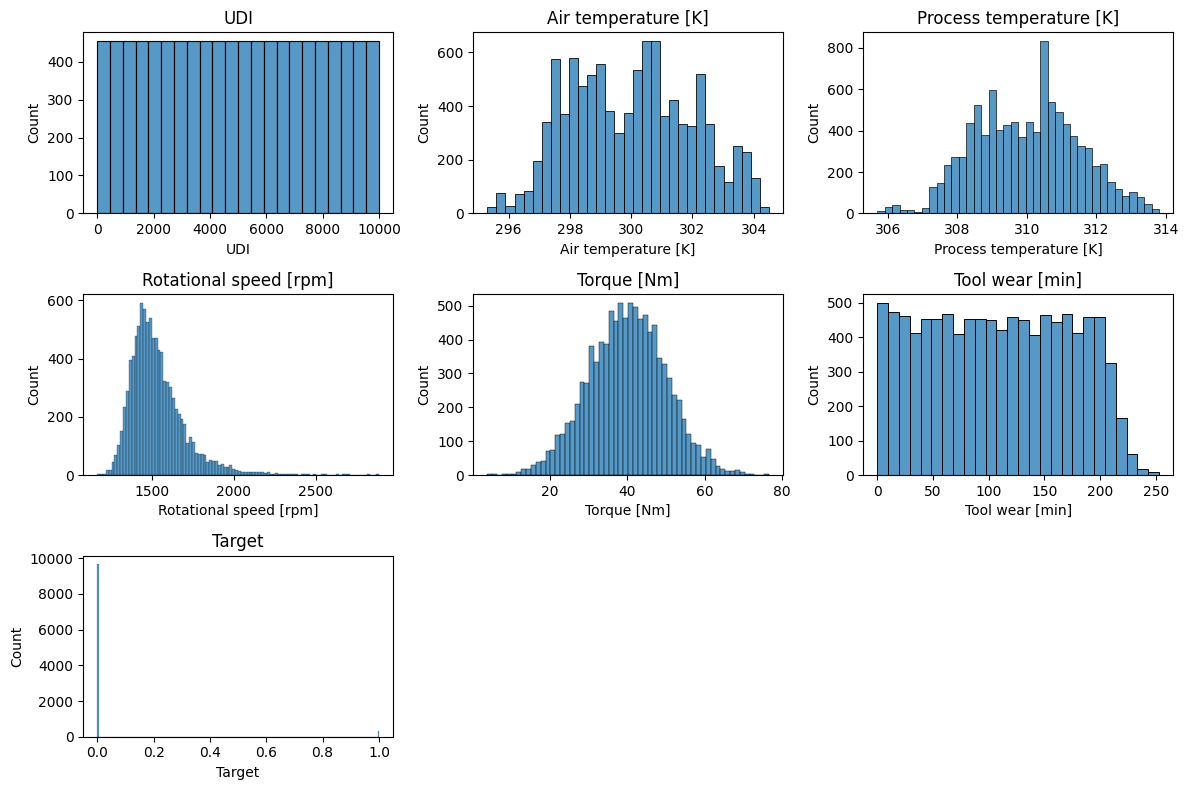

In [143]:
cols=dt.select_dtypes(include=["int64","float64"]).columns
plt.figure(figsize=(12,8))

for i,col in enumerate (cols):
    plt.subplot(3,3,i+1)
    sns.histplot(dt[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [144]:
#Type
dt["Type"].value_counts()

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

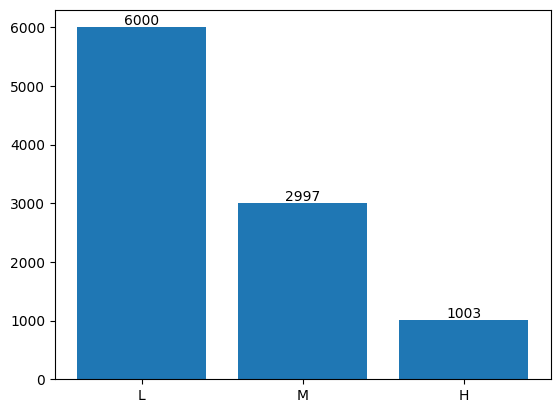

In [145]:
fig,ax=plt.subplots()

counts=dt["Type"].value_counts()

ax.bar(counts.index,counts.values)

for container in ax.containers:
    ax.bar_label(container)

plt.show()



In [146]:
#Target
dt["Target"].value_counts()

Target
0    9661
1     339
Name: count, dtype: int64

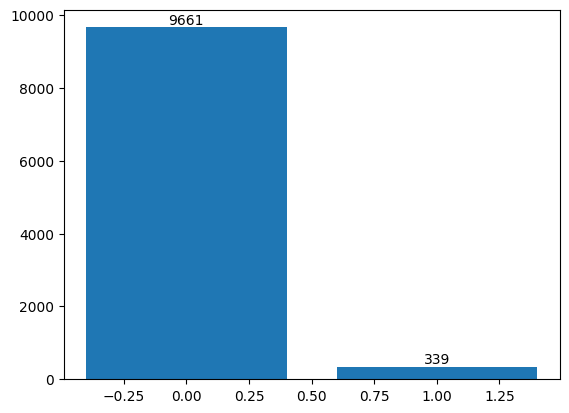

In [147]:
#Target

fig,ax=plt.subplots()

counts1=dt["Target"].value_counts()

ax.bar(counts1.index,counts1.values)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [148]:
dt.columns

Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Target'],
      dtype='object')

In [149]:
# Core relation

columns=['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]', 'Tool wear [min]']

corr_matrix=dt[columns].corr()

print(corr_matrix)

                         Air temperature [K]  Process temperature [K]  \
Air temperature [K]                 1.000000                 0.876107   
Process temperature [K]             0.876107                 1.000000   
Rotational speed [rpm]              0.022670                 0.019277   
Torque [Nm]                        -0.013778                -0.014061   
Tool wear [min]                     0.013853                 0.013488   

                         Rotational speed [rpm]  Torque [Nm]  Tool wear [min]  
Air temperature [K]                    0.022670    -0.013778         0.013853  
Process temperature [K]                0.019277    -0.014061         0.013488  
Rotational speed [rpm]                 1.000000    -0.875027         0.000223  
Torque [Nm]                           -0.875027     1.000000        -0.003093  
Tool wear [min]                        0.000223    -0.003093         1.000000  


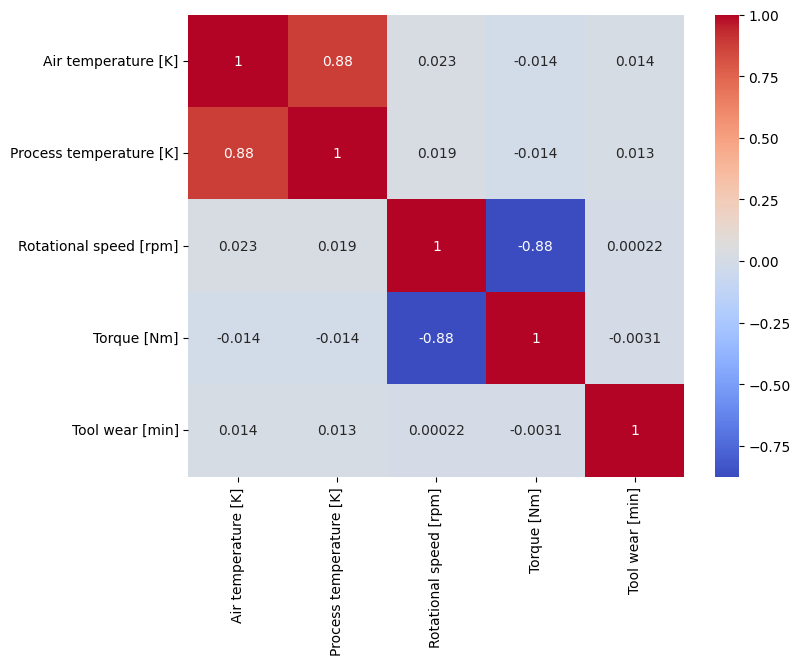

In [150]:
#heat map 
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix,annot=True,cmap='coolwarm')
plt.show()

In [151]:
# skewness
columns1=['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]', 'Tool wear [min]']

dt[columns1].skew()

Air temperature [K]        0.114274
Process temperature [K]    0.015027
Rotational speed [rpm]     1.993171
Torque [Nm]               -0.009517
Tool wear [min]            0.027292
dtype: float64

In [152]:
dt1=dt.copy()

In [153]:
from scipy.stats import boxcox
dt1["Rotational speed [rpm]_log"], lambda_ = boxcox(dt["Rotational speed [rpm]"])
print("Skewness after applying boxcox",dt1["Rotational speed [rpm]_log"].skew())

Skewness after applying boxcox 0.0


#### Outlier Detection

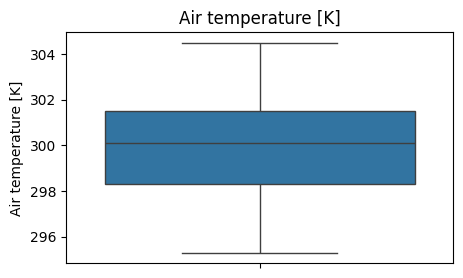

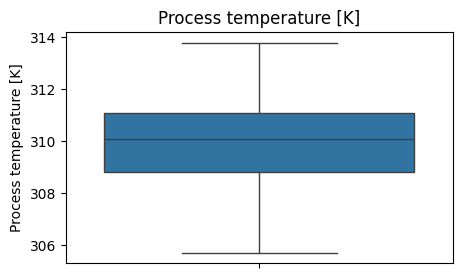

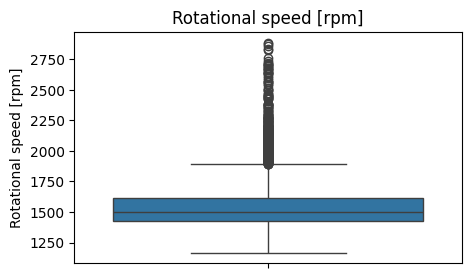

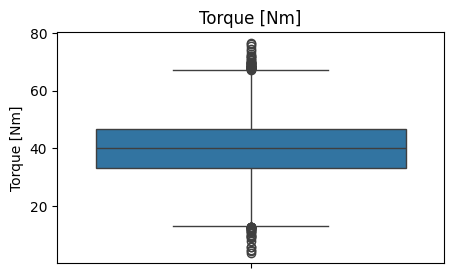

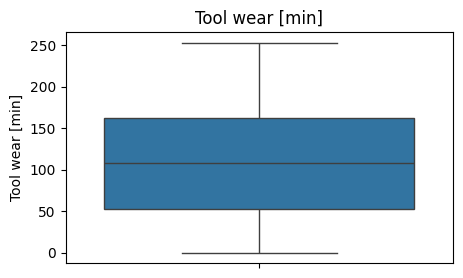

In [154]:
#Visualization to check Outliers 
columns2 =['Air temperature [K]','Process temperature [K]','Rotational speed [rpm]','Torque [Nm]', 'Tool wear [min]']


for col in columns2:
    plt.figure(figsize=(5,3))
    sns.boxplot(dt1[col])
    plt.title(col)
    plt.show()

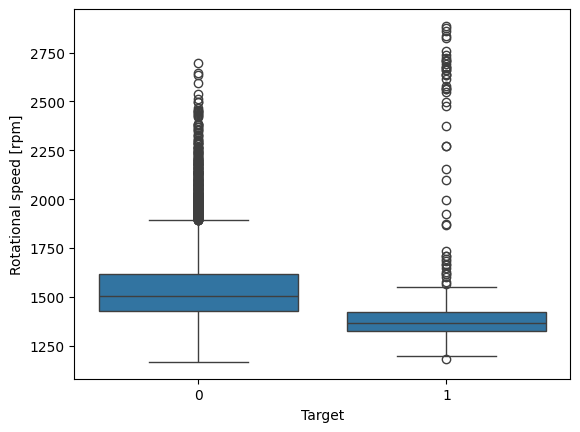

In [155]:
# Check Relationship with target 
sns.boxplot(x='Target',y='Rotational speed [rpm]',data =dt1)
plt.show()

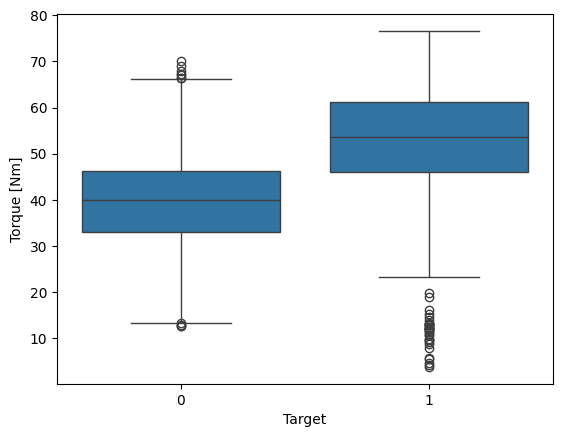

In [156]:
sns.boxplot(x='Target',y='Torque [Nm]',data=dt1)
plt.show()

#### Dropping Unnecessary columns 

In [157]:
dt1=dt1.drop(columns=["UDI","Product ID","Rotational speed [rpm]"])

In [158]:
dt1_encoded=dt1.copy()

#### Encoding-Ctaegorical Variable 

In [159]:
from sklearn.preprocessing import OrdinalEncoder
enc=OrdinalEncoder(categories=[["L","M","H"]])
dt1_encoded["Type"]=enc.fit_transform(dt[["Type"]])

#### Splitting the data 

In [160]:
X=dt1_encoded.drop("Target",axis=1)
y=dt1_encoded["Target"]



In [161]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)

#### Standard Scaling 

In [162]:
from sklearn.preprocessing import StandardScaler

In [163]:

scaler=StandardScaler()
num_cols=["Air temperature [K]","Process temperature [K]","Torque [Nm]","Tool wear [min]","Rotational speed [rpm]_log"]

X_train_scaled=X_train.copy()
X_test_scaled=X_test.copy()

X_train_scaled[num_cols]=scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols]=scaler.transform(X_test[num_cols])

#### Treating Class Imbalance (SMOTE)

In [164]:
from imblearn.over_sampling import SMOTE

In [165]:
smote=SMOTE(sampling_strategy=0.7,random_state=42)

In [166]:
X_train_smote,y_train_smote=smote.fit_resample(X_train_scaled,y_train)

In [167]:
y_train.value_counts()

Target
0    7246
1     254
Name: count, dtype: int64

In [168]:
y_train_smote.value_counts()

Target
0    7246
1    5072
Name: count, dtype: int64

#### Make Variable Simple

In [169]:
X_train1=X_train_smote.copy()
X_test1=X_test_scaled.copy()
y_train1=y_train_smote.copy()


## Modelling 

#### 1. Logistic Regression

In [170]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [171]:
#Model_Fitting
model=LogisticRegression(max_iter=1000,random_state=42)#class_weight='balanced')
model.fit(X_train1,y_train1)

# Predict on train and test 
y_train_pred=model.predict(X_train1)
y_test_pred=model.predict(X_test1)

# Train and Test Accuracy
train_acc=accuracy_score(y_train1,y_train_pred)
test_acc=accuracy_score(y_test,y_test_pred)

print("The Train Accuracy is:",train_acc)
print("The Test Accuracy is :",test_acc)
print("__"*50)

#confusion Matrix
cm=confusion_matrix(y_test,y_test_pred)
print("Confusion Matrix")
print(cm)
print("__"*50)
#Classification Report 
report=classification_report(y_test,y_test_pred)
print("classification_report")
print(report)

The Train Accuracy is: 0.7886020457866537
The Test Accuracy is : 0.842
____________________________________________________________________________________________________
Confusion Matrix
[[2046  369]
 [  26   59]]
____________________________________________________________________________________________________
classification_report
              precision    recall  f1-score   support

           0       0.99      0.85      0.91      2415
           1       0.14      0.69      0.23        85

    accuracy                           0.84      2500
   macro avg       0.56      0.77      0.57      2500
weighted avg       0.96      0.84      0.89      2500



#### 2. Decision Trees

In [172]:
from sklearn.tree import DecisionTreeClassifier

In [173]:
# Tree Model
dt_model=DecisionTreeClassifier(class_weight='balanced',random_state=42)

# Model Training 
dt_model.fit(X_train1,y_train1)

#Predict on train and test

y_train_pred=dt_model.predict(X_train1)
y_test_pred=dt_model.predict(X_test1)

# Train and Test Accuracy
Train_Accuracy=accuracy_score(y_train1,y_train_pred)
Test_Accuracy=accuracy_score(y_test,y_test_pred)
print("Train_Accuracy",Train_Accuracy)
print("Test_Accuracy",Test_Accuracy)
print("__"*50)

# Confusion Matrix
cm1=confusion_matrix(y_test,y_test_pred)
print("Confusion_Matrix")
print(cm1)
print("__"*50)

#classification_report


report1=classification_report(y_test,y_test_pred)
print("Classification_report")
print(report1)
                     
    

Train_Accuracy 1.0
Test_Accuracy 0.9676
____________________________________________________________________________________________________
Confusion_Matrix
[[2350   65]
 [  16   69]]
____________________________________________________________________________________________________
Classification_report
              precision    recall  f1-score   support

           0       0.99      0.97      0.98      2415
           1       0.51      0.81      0.63        85

    accuracy                           0.97      2500
   macro avg       0.75      0.89      0.81      2500
weighted avg       0.98      0.97      0.97      2500



#### 3.Random Forest

In [174]:
from sklearn.ensemble import RandomForestClassifier

In [175]:
rf=RandomForestClassifier(n_estimators=100,max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,class_weight='balanced')
#model Training 
rf.fit(X_train1,y_train1)

#Train and Test Prediction
y_train_pred=rf.predict(X_train1)
y_test_pred=rf.predict(X_test1)

#Train and test Accuracy
Train_accuracy=accuracy_score(y_train1,y_train_pred)
Test_accuracy=accuracy_score(y_test,y_test_pred)
print("Train Accuracy:",Train_accuracy)
print("Test Accuracy:",Test_accuracy)
print("__"*50)

#Confusion matrix
cm1=confusion_matrix(y_test,y_test_pred)
print(cm1)
print("__"*50)

#Classification_Report
print("Classification_Report")
print("__"*50)
report2=classification_report(y_test,y_test_pred)
print(report2)

Train Accuracy: 0.9755642149699627
Test Accuracy: 0.95
____________________________________________________________________________________________________
[[2306  109]
 [  16   69]]
____________________________________________________________________________________________________
Classification_Report
____________________________________________________________________________________________________
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      2415
           1       0.39      0.81      0.52        85

    accuracy                           0.95      2500
   macro avg       0.69      0.88      0.75      2500
weighted avg       0.97      0.95      0.96      2500



#### 4. XGBoost

In [176]:
X_train1.columns = X_train1.columns.str.replace(r'[\[\]]', '', regex=True)
X_test1.columns = X_test1.columns.str.replace(r'[\[\]]', '', regex=True)

In [177]:
from xgboost import XGBClassifier

In [178]:
from sklearn.metrics import classification_report, roc_auc_score

xg2=XGBClassifier(n_estimators=200,learning_rate=0.1,random_state=42)


#model

xg2.fit(X_train1,y_train1)

# train and test predict 
y_train_pred=xg.predict(X_train1)
y_test_pred=xg.predict(X_test1)

# Train and test accuracy 
train_accuracy=accuracy_score(y_train1,y_train_pred)
test_accuracy=accuracy_score(y_test,y_test_pred)
print("Train Accuracy:",train_accuracy)
print("Test Accuracy:",test_accuracy)
print("__"*50)
#Confusion Matrix

cm3=confusion_matrix(y_test,y_test_pred)
print(cm3)
print("__"*50)
# Classification_report
print("Classification_Report")
print("__"*50)
report3=classification_report(y_test,y_test_pred)
print(report3)

#ROC AND AUC SCORE 
print("__"*50)
print("ROC-AUC:", roc_auc_score(y_test,y_test_pred))


Train Accuracy: 0.9991069978892677
Test Accuracy: 0.9776
____________________________________________________________________________________________________
[[2375   40]
 [  16   69]]
____________________________________________________________________________________________________
Classification_Report
____________________________________________________________________________________________________
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2415
           1       0.63      0.81      0.71        85

    accuracy                           0.98      2500
   macro avg       0.81      0.90      0.85      2500
weighted avg       0.98      0.98      0.98      2500

____________________________________________________________________________________________________
ROC-AUC: 0.8976007794422116


### Hyper Parameter Tuning 

#### Randomized Search CV

In [179]:
from sklearn.model_selection import RandomizedSearchCV

In [180]:
param_dist={ 'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}

#### Rnadomized Search CV for Further Improvement 

In [181]:
from sklearn.model_selection import GridSearchCV

In [182]:
param_grid = {
    'n_estimators': [400, 500, 600],
    'learning_rate': [0.15, 0.2, 0.25],
    'max_depth': [4, 5, 6],
    'min_child_weight': [2, 3, 4],
    'subsample': [0.5, 0.6, 0.7],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0.05, 0.1, 0.2],
    'reg_alpha': [0.005, 0.01, 0.05],
    'reg_lambda': [1.0, 1.5, 2.0]
}

In [183]:
# XGBOOST AFTER HYPERPARAETER TUNING 

In [184]:
xgb1=XGBClassifier(subsample= 0.6, reg_lambda= 1.5, 
reg_alpha= 0.005, n_estimators= 600, min_child_weight= 2, 
max_depth= 6,learning_rate= 0.15, gamma= 0.1,colsample_bytree= 0.8)

xgb1.fit(X_train1,y_train1)

# train and test predict 
y_train_pred=xgb1.predict(X_train1)
y_test_pred=xgb1.predict(X_test1)

# Train and test accuracy 
train_accuracy=accuracy_score(y_train1,y_train_pred)
test_accuracy=accuracy_score(y_test,y_test_pred)
print("Train Accuracy:",train_accuracy)
print("Test Accuracy:",test_accuracy)
print("__"*50)
#Confusion Matrix

cm3=confusion_matrix(y_test,y_test_pred)
print(cm3)
print("__"*50)
# Classification_report
print("Classification_Report")
print("__"*50)
report3=classification_report(y_test,y_test_pred)
print(report3)

Train Accuracy: 0.9998376359798669
Test Accuracy: 0.9764
____________________________________________________________________________________________________
[[2378   37]
 [  22   63]]
____________________________________________________________________________________________________
Classification_Report
____________________________________________________________________________________________________
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      2415
           1       0.63      0.74      0.68        85

    accuracy                           0.98      2500
   macro avg       0.81      0.86      0.83      2500
weighted avg       0.98      0.98      0.98      2500



In [185]:
import joblib

In [186]:
import joblib
joblib.dump(scaler,"scaler.pkl")
joblib.dump(xg2,"xgb_model.pkl")
joblib.dump(lambda_,"boxcox_lambda.pkl")

['boxcox_lambda.pkl']

In [187]:
 xg2.feature_names_in_

array(['Type', 'Air temperature K', 'Process temperature K', 'Torque Nm',
       'Tool wear min', 'Rotational speed rpm_log'], dtype='<U24')

In [188]:
pip show scikit-learn


Name: scikit-learn
Version: 1.8.0
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License-Expression: BSD-3-Clause
Location: c:\Users\Lenovo\Desktop\deployment\random\myenv\Lib\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: imbalanced-learn, shap, sklearn-compat
Note: you may need to restart the kernel to use updated packages.


In [189]:
pip show xgboost

Name: xgboost
Version: 3.2.0
Summary: XGBoost Python Package
Home-page: 
Author: 
Author-email: Hyunsu Cho <chohyu01@cs.washington.edu>, Jiaming Yuan <jm.yuan@outlook.com>
License: Apache-2.0
Location: c:\Users\Lenovo\Desktop\deployment\random\myenv\Lib\site-packages
Requires: numpy, scipy
Required-by: 
Note: you may need to restart the kernel to use updated packages.
